In [11]:
import numpy as np 
import matplotlib.pyplot as plt 
from AFL.double_agent_tutorial.instruments.challenge2 import get_virtual_instrument 

In [12]:
instrument = get_virtual_instrument()

In [13]:
instrument.boundary_dataset

<xarray.Dataset> Size: 181kB
Dimensions:  (grid: 5650)
Dimensions without coordinates: grid
Data variables:
    a        (grid) float64 45kB 0.0 0.0 0.0 0.0 0.0 ... 0.9849 0.9899 0.995 1.0
    b        (grid) float64 45kB 0.0 0.0101 0.0202 ... 0.01005 0.005025 0.0
    c        (grid) float64 45kB 1.0 0.9899 0.9798 0.9697 ... -0.01 -0.01 -0.01
    labels   (grid) <U2 45kB 'L2' 'L2' 'L2' 'L2' 'L2' ... 'D' 'D' 'D' 'D' 'D'
Attributes:
    components:  ['c', 'a', 'b']
    labels:      labels

In [14]:
def set_axislabels_mpltern(ax):
    """ 
    Sets axis labels for phase plots using mpltern 
    in the order of solvent (index 2), polymer (index 0), non-solvent (index 1)
    """
    ax.set_tlabel(r'$\phi_3$', fontsize=15)
    ax.set_llabel(r'$\phi_1$', fontsize=15)
    ax.set_rlabel(r'$\phi_2$', fontsize=15)
    ax.taxis.set_label_position('tick1')
    ax.laxis.set_label_position('tick1')
    ax.raxis.set_label_position('tick1')  

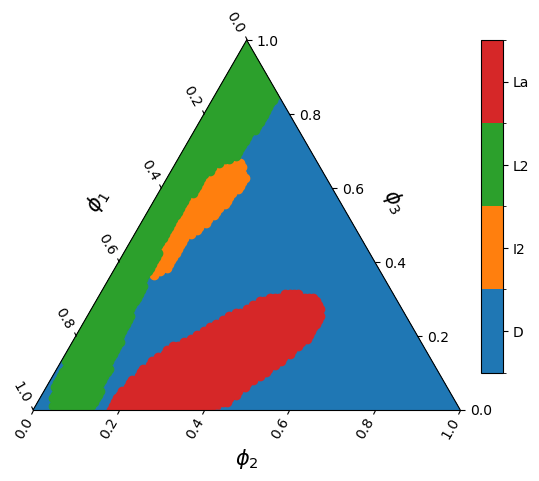

In [15]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import mpltern

phases = np.unique(instrument.boundary_dataset['labels'])

base_cmap = plt.get_cmap('tab10') 
colors = base_cmap.colors
N = len(phases)
selected_colors = [colors[i % 10] for i in range(N)]
cmap = mcolors.ListedColormap(selected_colors, name=f'tab10_{N}')
boundaries = np.linspace(0, N+1, N+1)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)
mappable = ScalarMappable(norm=norm, cmap=cmap)

fig, ax = plt.subplots(subplot_kw={'projection': 'ternary'})
for i,label in enumerate(phases):
    idx = instrument.boundary_dataset['labels'] == label
    ax.scatter(instrument.boundary_dataset['c'][idx], 
               instrument.boundary_dataset['a'][idx], 
               instrument.boundary_dataset['b'][idx],
               color = selected_colors[i]
            )
set_axislabels_mpltern(ax)
cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
cbar = fig.colorbar(mappable, shrink=0.5, aspect=5, cax=cax)
tick_locs = cax.get_yticks()  
new_tick_locs = (tick_locs[:-1] + tick_locs[1:]) / 2
cbar.set_ticks(new_tick_locs)
cbar.ax.set_yticklabels(phases.tolist())
plt.show()